## Amazon Fine Food Reviews

In [1]:
# pip install pandas numpy matplotlib seaborn wordcloud nltk spacy scikit-learn gensim tensorflow jupyter


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Display settings
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style — clean and professional
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

COLORS = {
    'Positive': '#1D9E75',   # teal
    'Neutral':  '#EF9F27',   # amber
    'Negative': '#E24B4A',   # red
}

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
df = pd.read_csv("D:\hilearn\Machine Learning\Project\Customer Review\data\Reviews.csv")

print(f"Shape: {df.shape}")
df.head(5)

Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The pr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this w...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in thi..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taff...


In [5]:
print(f"Columns: {df.columns.tolist()}")

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [6]:
def map_sentiment(score):
    if score >= 4:   
        return 'Positive'
    elif score == 3: 
        return 'Neutral'
    else:            
        return 'Negative'

df['sentiment'] = df['Score'].apply(map_sentiment)

# Keep only relevant columns
df = df[['Score', 'Summary', 'Text', 'sentiment']].copy()

# Drop nulls in Text (our main feature)
df.dropna(subset=['Text'], inplace=True)

print(f"After cleaning: {df.shape[0]:,} rows")
print(df['sentiment'].value_counts())

After cleaning: 568,454 rows
sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


In [7]:
# Nulls per column
print("=== Null Values ===")
print(df.isnull().sum())

=== Null Values ===
Score         0
Summary      27
Text          0
sentiment     0
dtype: int64


In [8]:
# Duplicate reviews (same text, different row)
dupes = df.duplicated(subset='Text', keep=False).sum()
print(f"\n=== Duplicate review texts: {dupes:,} ===")




=== Duplicate review texts: 232,915 ===


In [9]:

# Remove duplicates — keep first occurrence
df.drop_duplicates(subset='Text', keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After dedup: {df.shape[0]:,} rows")

After dedup: 393,579 rows


In [10]:
# import os
# os.makedirs('../outputs', exist_ok=True)
# os.makedirs('../data', exist_ok=True)
# print("✅ Folders created")

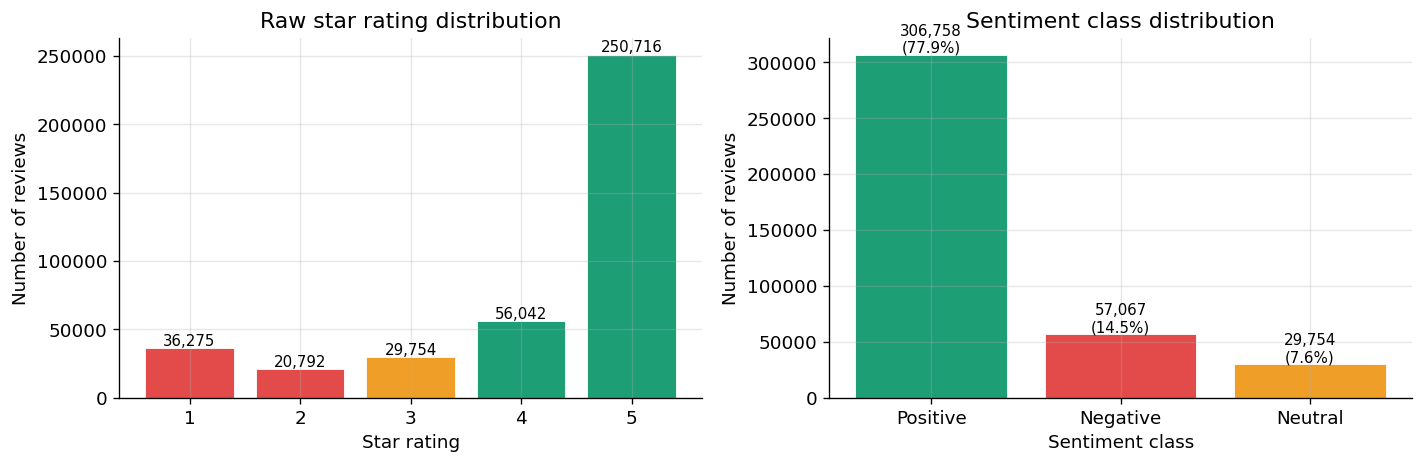

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw star rating counts
star_counts = df['Score'].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values,
            color=[COLORS['Negative'], COLORS['Negative'],
                   COLORS['Neutral'],
                   COLORS['Positive'], COLORS['Positive']],
            edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Raw star rating distribution')
for i, (x, v) in enumerate(zip(star_counts.index, star_counts.values)):
    axes[0].text(x, v + 2000, f'{v:,}', ha='center', fontsize=9)

# Right: mapped sentiment class counts
sent_counts = df['sentiment'].value_counts()
colors_list = [COLORS[s] for s in sent_counts.index]
axes[1].bar(sent_counts.index, sent_counts.values,
            color=colors_list, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Sentiment class')
axes[1].set_ylabel('Number of reviews')
axes[1].set_title('Sentiment class distribution')
for x, v in zip(sent_counts.index, sent_counts.values):
    pct = v / len(df) * 100
    axes[1].text(x, v + 2000, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/01_class_distribution.png', bbox_inches='tight')
plt.show()

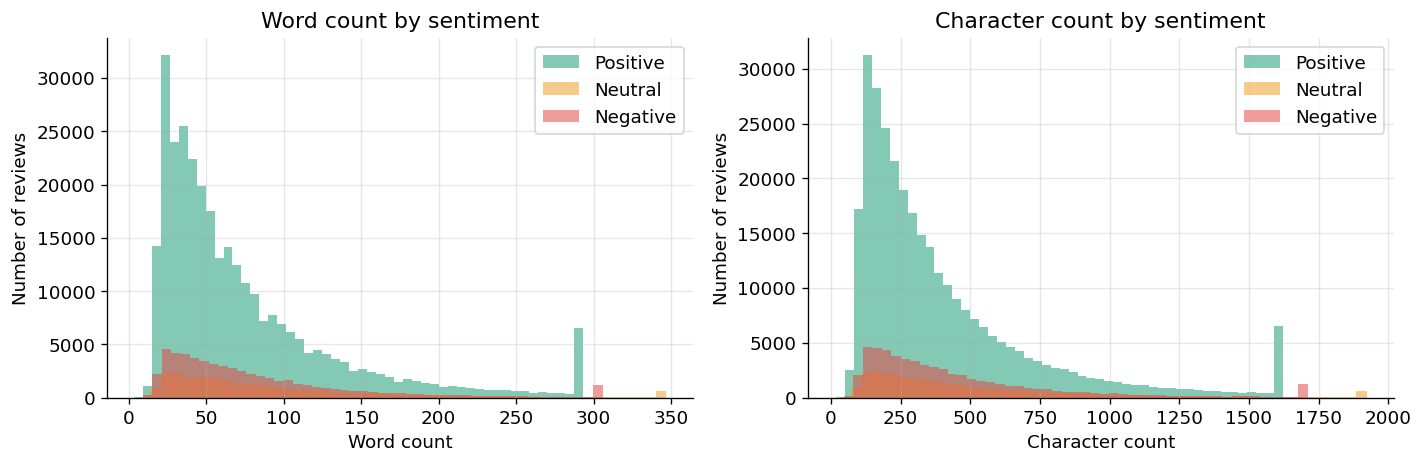

          word_count                                             char_count  \
               count  mean   std  min   25%   50%    75%     max      count   
sentiment                                                                     
Negative    57067.00 85.30 78.80 3.00 38.00 63.00 105.00 2149.00   57067.00   
Neutral     29754.00 96.20 88.80 7.00 41.00 70.00 122.00 3432.00   29754.00   
Positive   306758.00 77.10 75.40 3.00 33.00 54.00  94.00 2520.00  306758.00   

                                                             
            mean    std   min    25%    50%    75%      max  
sentiment                                                    
Negative  466.50 444.70 12.00 204.00 342.00 569.00 11861.00  
Neutral   524.20 501.40 32.00 217.00 376.00 658.80 21409.00  
Positive  419.00 422.10 18.00 175.00 291.00 506.00 16952.00  


In [12]:
# Add length features
df['word_count']  = df['Text'].apply(lambda x: len(str(x).split()))
df['char_count']  = df['Text'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes,
                           ['word_count', 'char_count'],
                           ['Word count', 'Character count']):
    for sentiment, color in COLORS.items():
        subset = df[df['sentiment'] == sentiment][col]
        ax.hist(subset.clip(upper=subset.quantile(0.98)),
                bins=50, alpha=0.55, label=sentiment,
                color=color, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of reviews')
    ax.set_title(f'{label} by sentiment')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/02_review_lengths.png', bbox_inches='tight')
plt.show()

# Summary stats
print(df.groupby('sentiment')[['word_count', 'char_count']].describe().round(1))


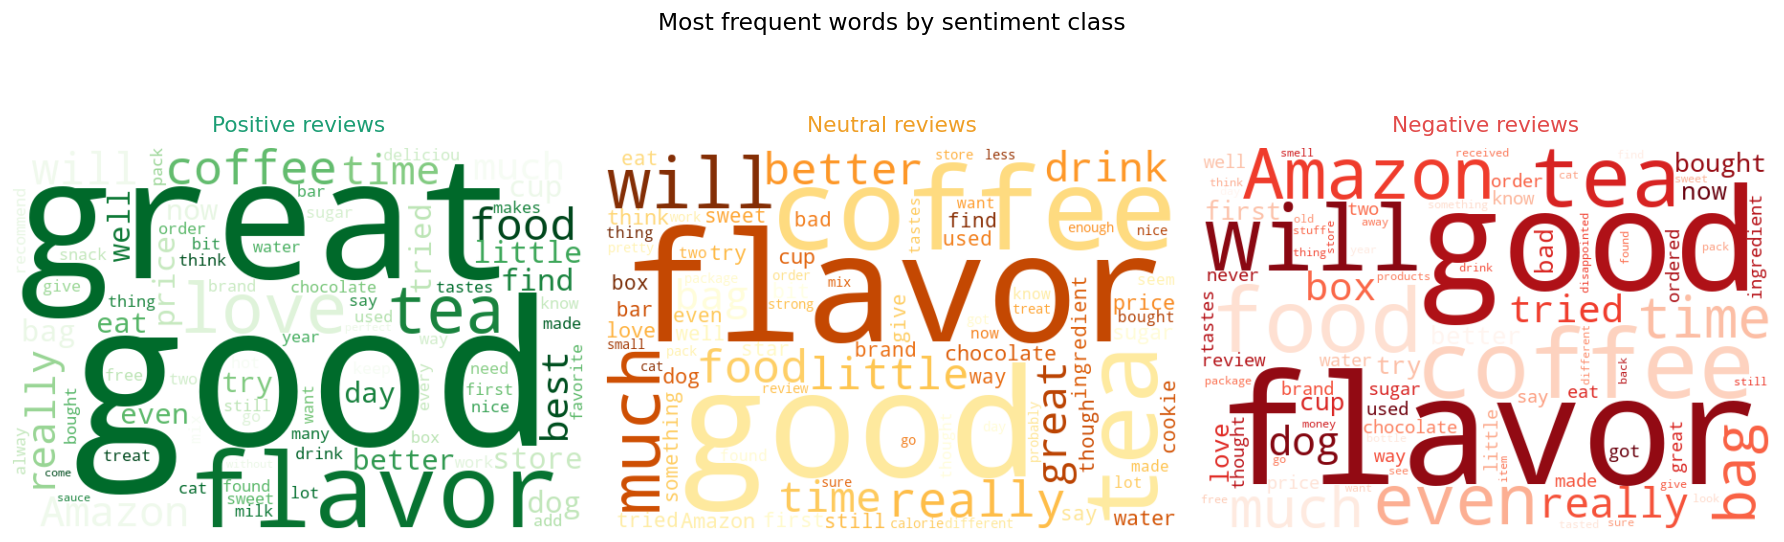

In [13]:
from wordcloud import WordCloud, STOPWORDS

# Extend default stopwords with domain noise
EXTRA_STOPS = {'br', 'product', 'one', 'would', 'get', 'also', 'make',
               'taste', 'like', 'use', 'buy', 'im', 'ive', 'dont'}
stopwords = STOPWORDS.union(EXTRA_STOPS)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
wc_colors = {'Positive': 'Greens', 'Neutral': 'YlOrBr', 'Negative': 'Reds'}

for ax, (sentiment, cmap) in zip(axes, wc_colors.items()):
    text_blob = ' '.join(df[df['sentiment'] == sentiment]['Text'].astype(str))
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=cmap,
        stopwords=stopwords,
        max_words=80,
        collocations=False,
    ).generate(text_blob)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} reviews', fontsize=13, fontweight='500',
                 color=COLORS[sentiment], pad=10)

plt.suptitle('Most frequent words by sentiment class', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/03_wordclouds.png', bbox_inches='tight')
plt.show()

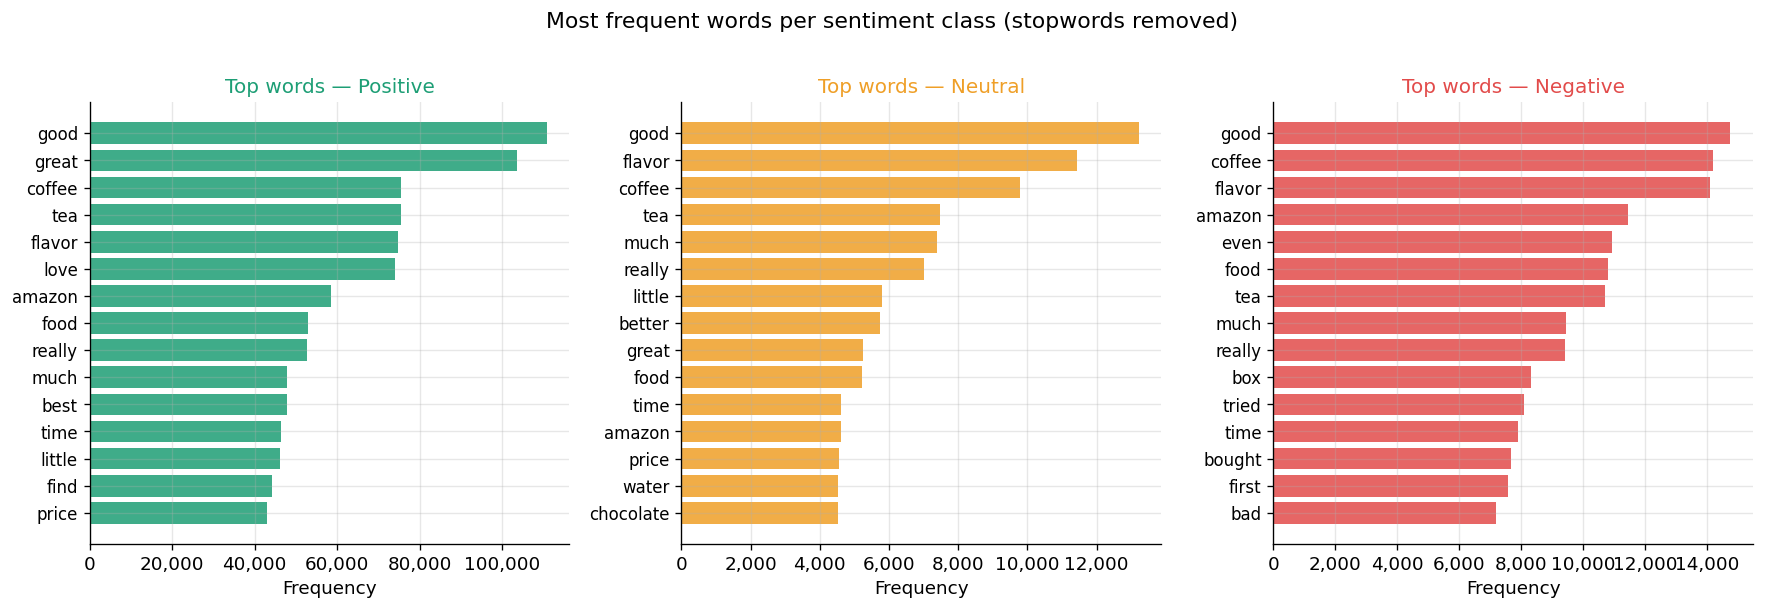

In [15]:
from collections import Counter  
import nltk
from nltk.corpus import stopwords as nltk_stops
nltk.download('stopwords', quiet=True)

SW = set(nltk_stops.words('english')).union(EXTRA_STOPS)

def get_top_words(df_subset, n=15):
    words = []
    for text in df_subset['Text'].astype(str):
        tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
        words.extend([w for w in tokens if w not in SW])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    top = get_top_words(df[df['sentiment'] == sentiment])
    words, counts = zip(*top)
    bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                   color=COLORS[sentiment], alpha=0.85, edgecolor='none')
    ax.set_title(f'Top words — {sentiment}', color=COLORS[sentiment], fontsize=12)
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Most frequent words per sentiment class (stopwords removed)', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/04_top_words.png', bbox_inches='tight')
plt.show()

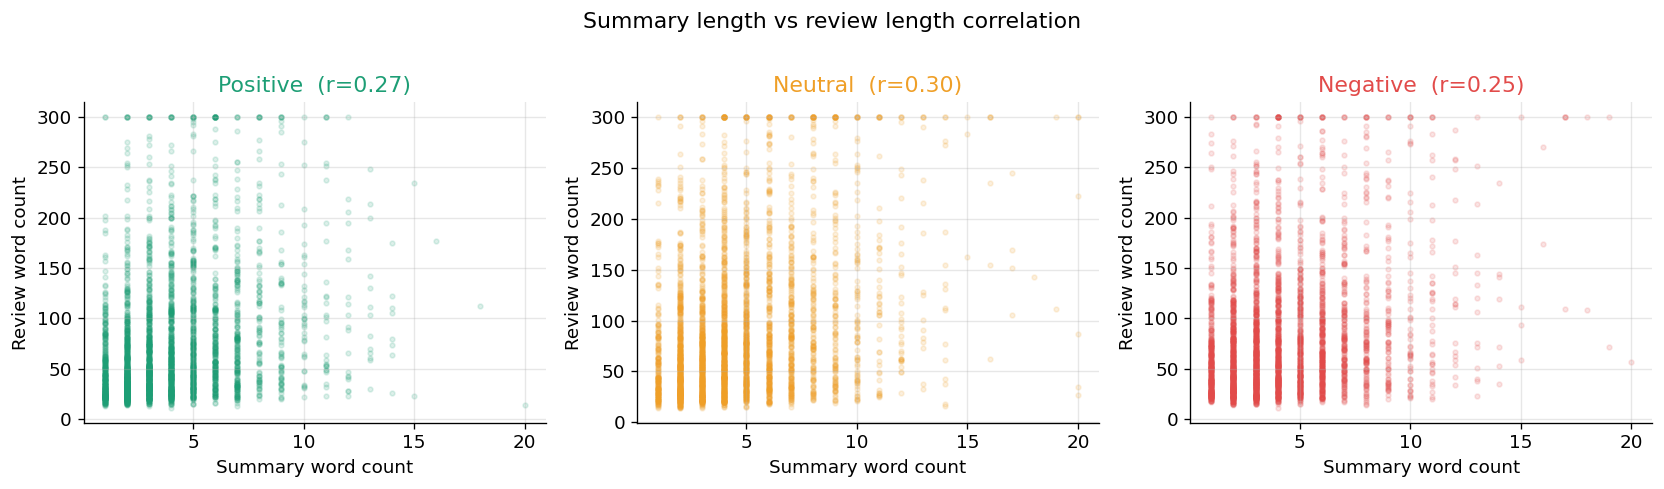

In [16]:
# Do longer summaries correlate with more words in the review text?
df['summary_word_count'] = df['Summary'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    sub = df[df['sentiment'] == sentiment].sample(min(3000, len(df)), random_state=42)
    ax.scatter(sub['summary_word_count'].clip(upper=20),
               sub['word_count'].clip(upper=300),
               alpha=0.15, s=8, color=COLORS[sentiment])
    corr = sub['summary_word_count'].corr(sub['word_count'])
    ax.set_title(f'{sentiment}  (r={corr:.2f})', color=COLORS[sentiment])
    ax.set_xlabel('Summary word count')
    ax.set_ylabel('Review word count')

plt.suptitle('Summary length vs review length correlation', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/05_summary_vs_text.png', bbox_inches='tight')
plt.show()